In [ ]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array # Corrected import
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
path = kagglehub.dataset_download("jiscecseaiml/fruit-classification-dataset")
print("Path to dataset files:", path)

100%|██████████| 0.99G/0.99G [00:07<00:00, 151MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jiscecseaiml/fruit-classification-dataset/versions/1


In [ ]:
dataset_path = os.path.join(path, 'Fruit classification dataset')
train_folder = os.path.join(dataset_path, 'Training-20250515T045937Z-1-001', 'Training')
test_folder = os.path.join(dataset_path, 'Test-20250515T045722Z-1-001', 'Test')

In [ ]:
print("Train folders:", os.listdir(train_folder))
print("Test folders:", os.listdir(test_folder))


Train folders: ['Fresh Banana', 'Rotten Apples', 'Rotten Banana', 'Rotten Oranges', 'Fresh Oranges', 'Fresh Apples']
Test folders: ['Fresh Banana', 'Rotten Apples', 'Rotten Banana', 'Rotten Oranges', 'Fresh Oranges', 'Fresh Apples']


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_folder,
                                              target_size=(150,150),
                                              batch_size=32,
                                              class_mode='categorical')

val_gen = val_datagen.flow_from_directory(test_folder,
                                          target_size=(150,150),
                                          batch_size=32,
                                          class_mode='categorical')


Found 6508 images belonging to 6 classes.
Found 1593 images belonging to 6 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_gen, epochs=30, validation_data=val_gen)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.5523 - loss: 1.1443 - val_accuracy: 0.8387 - val_loss: 0.5068
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.8347 - loss: 0.4933 - val_accuracy: 0.8682 - val_loss: 0.3878
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.8564 - loss: 0.4118 - val_accuracy: 0.8393 - val_loss: 0.3790
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.8671 - loss: 0.3719 - val_accuracy: 0.9027 - val_loss: 0.2659
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.9035 - loss: 0.3009 - val_accuracy: 0.8989 - val_loss: 0.2640
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.8948 - loss: 0.2942 - val_accuracy: 0.9196 - val_loss: 0.2345
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9112 - loss: 0.2615 - val_accuracy: 0.9234 - val_loss: 0.2278
Epoch 8/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.9201 - loss: 0.2245 - val_accu

In [ ]:
# ✅ List of five valid test image paths (each path separately)
test_image_paths = [
   '/content/apple f.webp',
    '/content/banana f.webp'

]

# ✅ Loop through each image and predict
for img_path in test_image_paths:
    try:
        img = image.load_img(img_path, target_size=(150,150))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.

        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        class_labels = list(train_gen.class_indices.keys())
        predicted_label = class_labels[predicted_class_index]

        # ✅ Determine freshness
        if 'Fresh' in predicted_label:
            freshness = "Fresh"
        else:
            freshness = "Rotten"

        # ✅ Display image with prediction
        plt.figure(figsize=(3,3))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {freshness} ({predicted_label})")
        plt.show()
    except Exception as e:
        print(f"Error processing {img_path}: {e}")


Error processing /content/apple f.webp: name 'image' is not defined
Error processing /content/banana f.webp: name 'image' is not defined


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


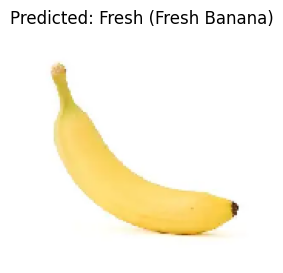

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


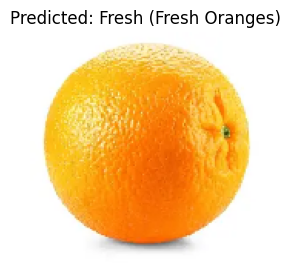

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


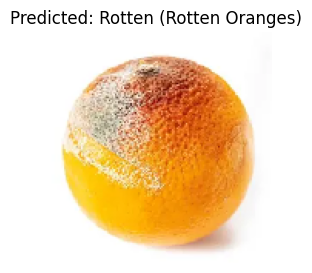

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


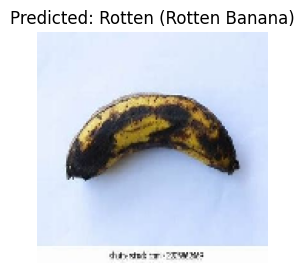

In [ ]:
# ✅ List of image paths to predict
test_image_paths = [
    '/content/banana f.webp',
    '/content/orange f.webp',
    '/content/orange r.webp',
    '/content/banan r.jpg'
]

# ✅ Loop through each image path
for img_path in test_image_paths:
    try:
        # Load image using the given path
        img = load_img(img_path, target_size=(150,150))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.

        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        class_labels = list(train_gen.class_indices.keys())
        predicted_label = class_labels[predicted_class_index]

        # Determine freshness
        if 'Fresh' in predicted_label:
            freshness = "Fresh"
        else:
            freshness = "Rotten"

        # Display image with prediction
        plt.figure(figsize=(3,3))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {freshness} ({predicted_label})")
        plt.show()
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
